In [1]:
"""
Bayesian Neural Network target for the Sticky Boomerang Sampler.

The parameter vector θ is a flat array containing all weights and biases:
    θ = [W1.ravel(), b1, W2.ravel(), b2, ...]

Spike-and-slab prior on weights (not biases):
    w_ij ~ w * N(0, σ²) + (1-w) * δ_0      (weights)
    b_j  ~ N(0, σ_b²)                        (biases — always active, no spike)

This means κ should be set per-parameter:
    κ_i = w/(1-w) * 1/(σ√2π)   for weights
    κ_i = ∞  (or very large)    for biases (never freeze)
"""

import autograd.numpy as anp
import numpy as np
import os
os.chdir('..')
os.getcwd()



'/Users/augustarnstad/Documents/sticky_samplers/sticky_bnns'

In [2]:
np.random.seed(42)
n, d_in = 500, 5
X = np.random.randn(n, d_in)

# Only x0 and x2 matter — nonlinear relationship
logits = 2.0 * np.tanh(1.5 * X[:, 0] - 0.5 * X[:, 2]) \
       - 1.0 * np.tanh(X[:, 0] + 1.2 * X[:, 2])
y = (np.random.rand(n) < 1.0 / (1.0 + np.exp(-logits))).astype(float)

print(f"Class balance: {y.mean():.2f}")

Class balance: 0.52


In [3]:
from bnn_testing.bnn_warmstart import warmstart_bnn

H=10

ws = warmstart_bnn(X, y, [d_in, H, 1])

Warm-start: [5, 10, 1]  (D=71)
  Training with Adam...
    epoch     0/3000  nll=355.5  acc=0.516
    epoch   500/3000  nll=235.8  acc=0.774
    epoch  1000/3000  nll=203.3  acc=0.820
    epoch  1500/3000  nll=187.2  acc=0.834
    epoch  2000/3000  nll=180.7  acc=0.850
    epoch  2500/3000  nll=176.5  acc=0.852
    epoch  2999/3000  nll=173.7  acc=0.856
  Train accuracy: 0.856
  σ_w per layer: ['2.241', '2.163']
  Computing Fisher...
  Σ⁻¹ eigenvalues: [0.1993, 1.3459]
  Ready. (x_ref acc=0.856)


In [4]:
w_prior = 0.2
sigma_w = np.mean(ws["sigma_w_layers"])
kappa = np.empty(ws["D"])
kappa[ws["weight_mask"]] = w_prior / (1 - w_prior) / (sigma_w * np.sqrt(2 * np.pi))
kappa[~ws["weight_mask"]] = 1e6

In [5]:
from sazz.samplers.boomerang_sampler.StickyBoomerangSampler import StickyBoomerangSampler
from personal.OLD.bnn_preprocess import preprocess_bnn
N=10000

sampler = StickyBoomerangSampler(
    E=ws["E"], N=N, D=ws["D"],
    grad_target=ws["gradE"], kappa=kappa,
)
sampler.preprocess(method="manual", x_ref=ws["x_ref"], Sigma_inv=ws["Sigma_inv"])

In [6]:
sampler.sample_auto()

Sticky Boomerang time: 100%|█████████▉| 9999/10000 [00:38<00:00, 262.83iter/s, time=271.176]

Time passed: 271.17639368787223


In [7]:
np.random.seed(99)
n_test = 200
X_test = np.random.randn(n_test, d_in)

logits_test = 2.0 * np.tanh(1.5 * X_test[:, 0] - 0.5 * X_test[:, 2]) \
            - 1.0 * np.tanh(X_test[:, 0] + 1.2 * X_test[:, 2])
y_test = (np.random.rand(n_test) < 1.0 / (1.0 + np.exp(-logits_test))).astype(float)

In [8]:
from sazz.samplers.boomerang_sampler.utils import resample_sticky_pdmp_path
from bnn_testing.bnn_warmstart import _forward, _sigmoid

t, x = resample_sticky_pdmp_path(sampler, n_samples=4000)

# Skip burn-in, take evenly spaced samples
burn = len(t) // 5
sample_idx = np.linspace(burn, len(t) - 1, 200, dtype=int)

all_probs = np.array([
    _sigmoid(_forward(x[i], X_test, ws["shapes"], ws["slices"]))
    for i in sample_idx
])

mean_probs = all_probs.mean(axis=0)
preds = (mean_probs > 0.5).astype(float)

print(f"Test accuracy: {np.mean(preds == y_test):.3f}")
print(f"Mean predicted prob (y=1): {mean_probs[y_test == 1].mean():.3f}")
print(f"Mean predicted prob (y=0): {mean_probs[y_test == 0].mean():.3f}")

weight_mask = ws["weight_mask"]
active_frac = np.mean([
    np.mean(np.abs(x[i][weight_mask]) > 1e-10)
    for i in sample_idx
])
print(f"Average active weights: {active_frac:.1%} of {weight_mask.sum()}")

Test accuracy: 0.770
Mean predicted prob (y=1): 0.725
Mean predicted prob (y=0): 0.355
Average active weights: 35.2% of 60


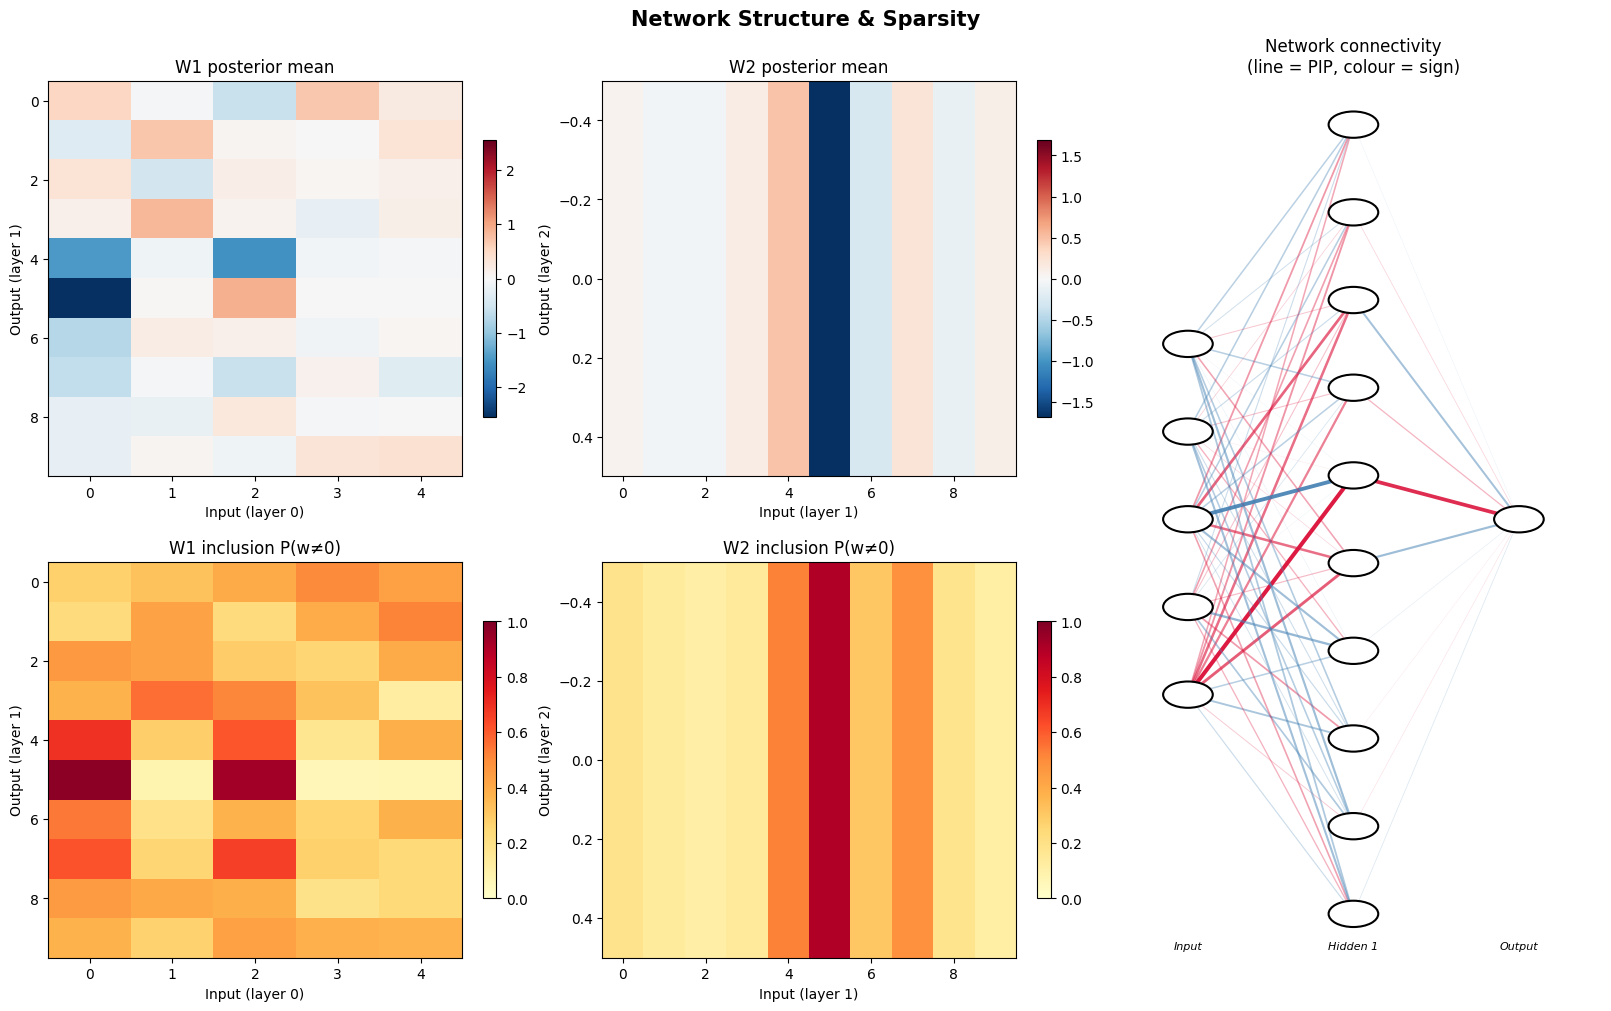

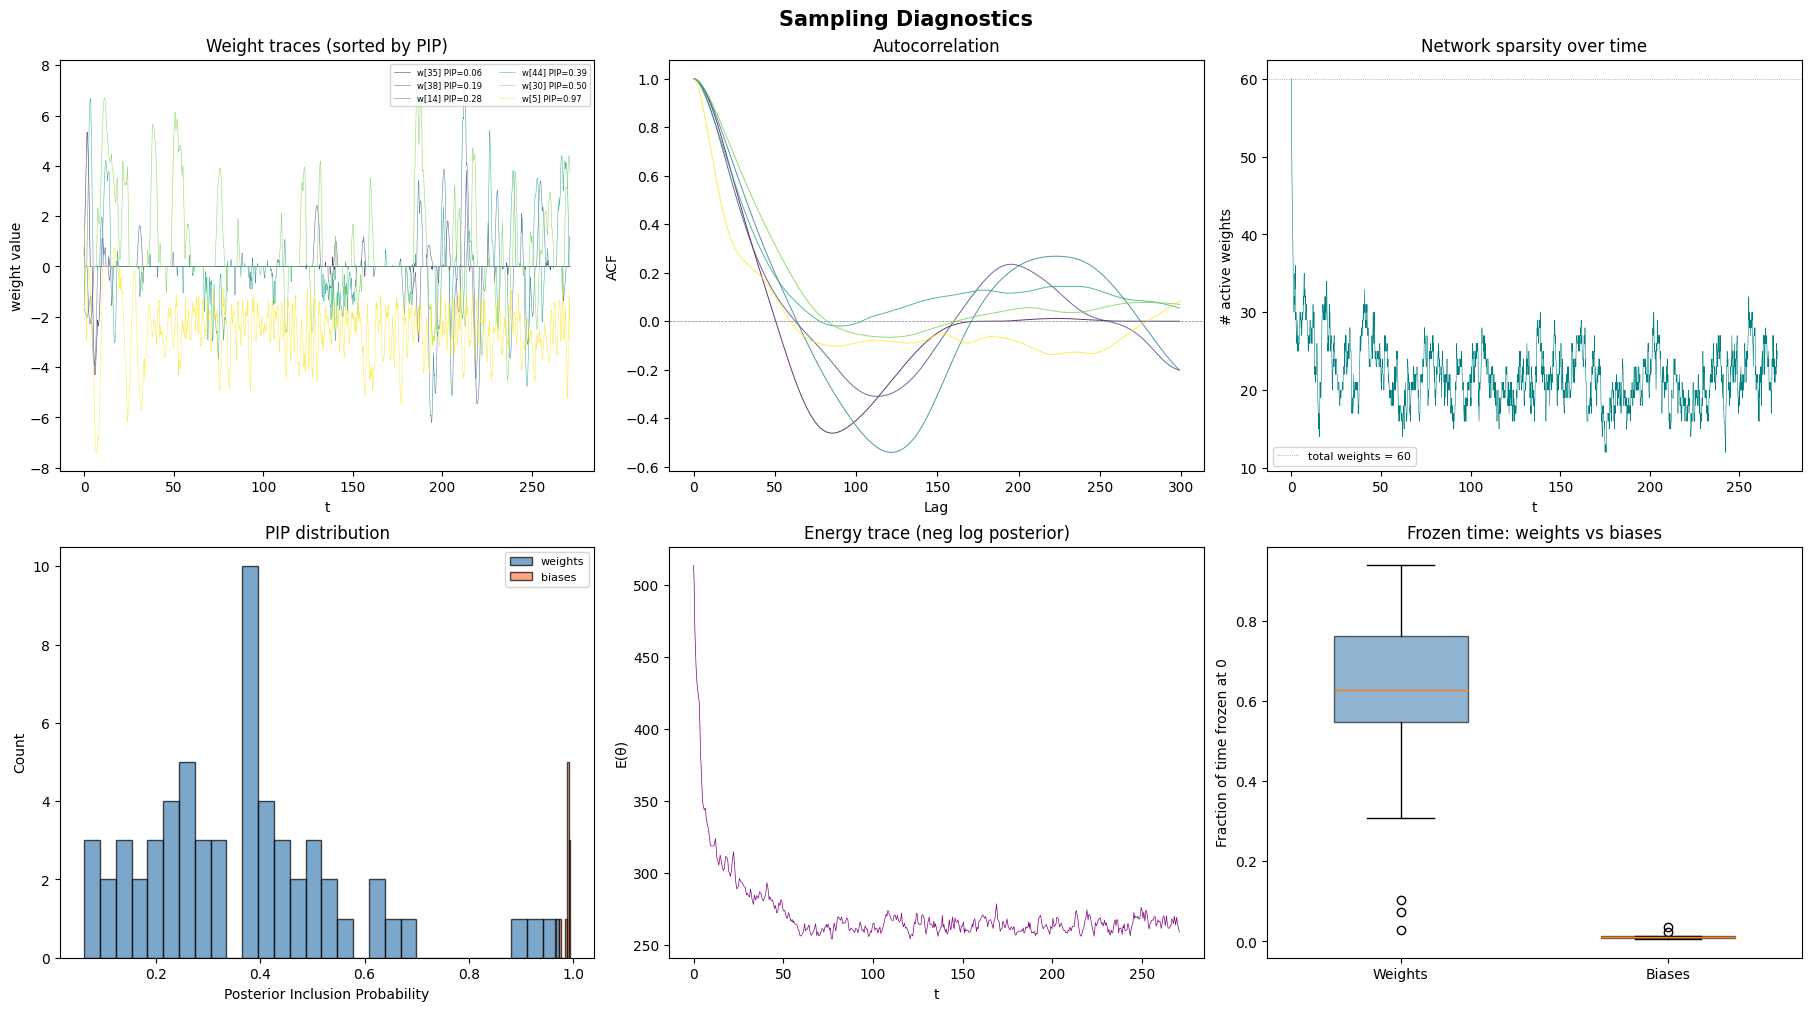

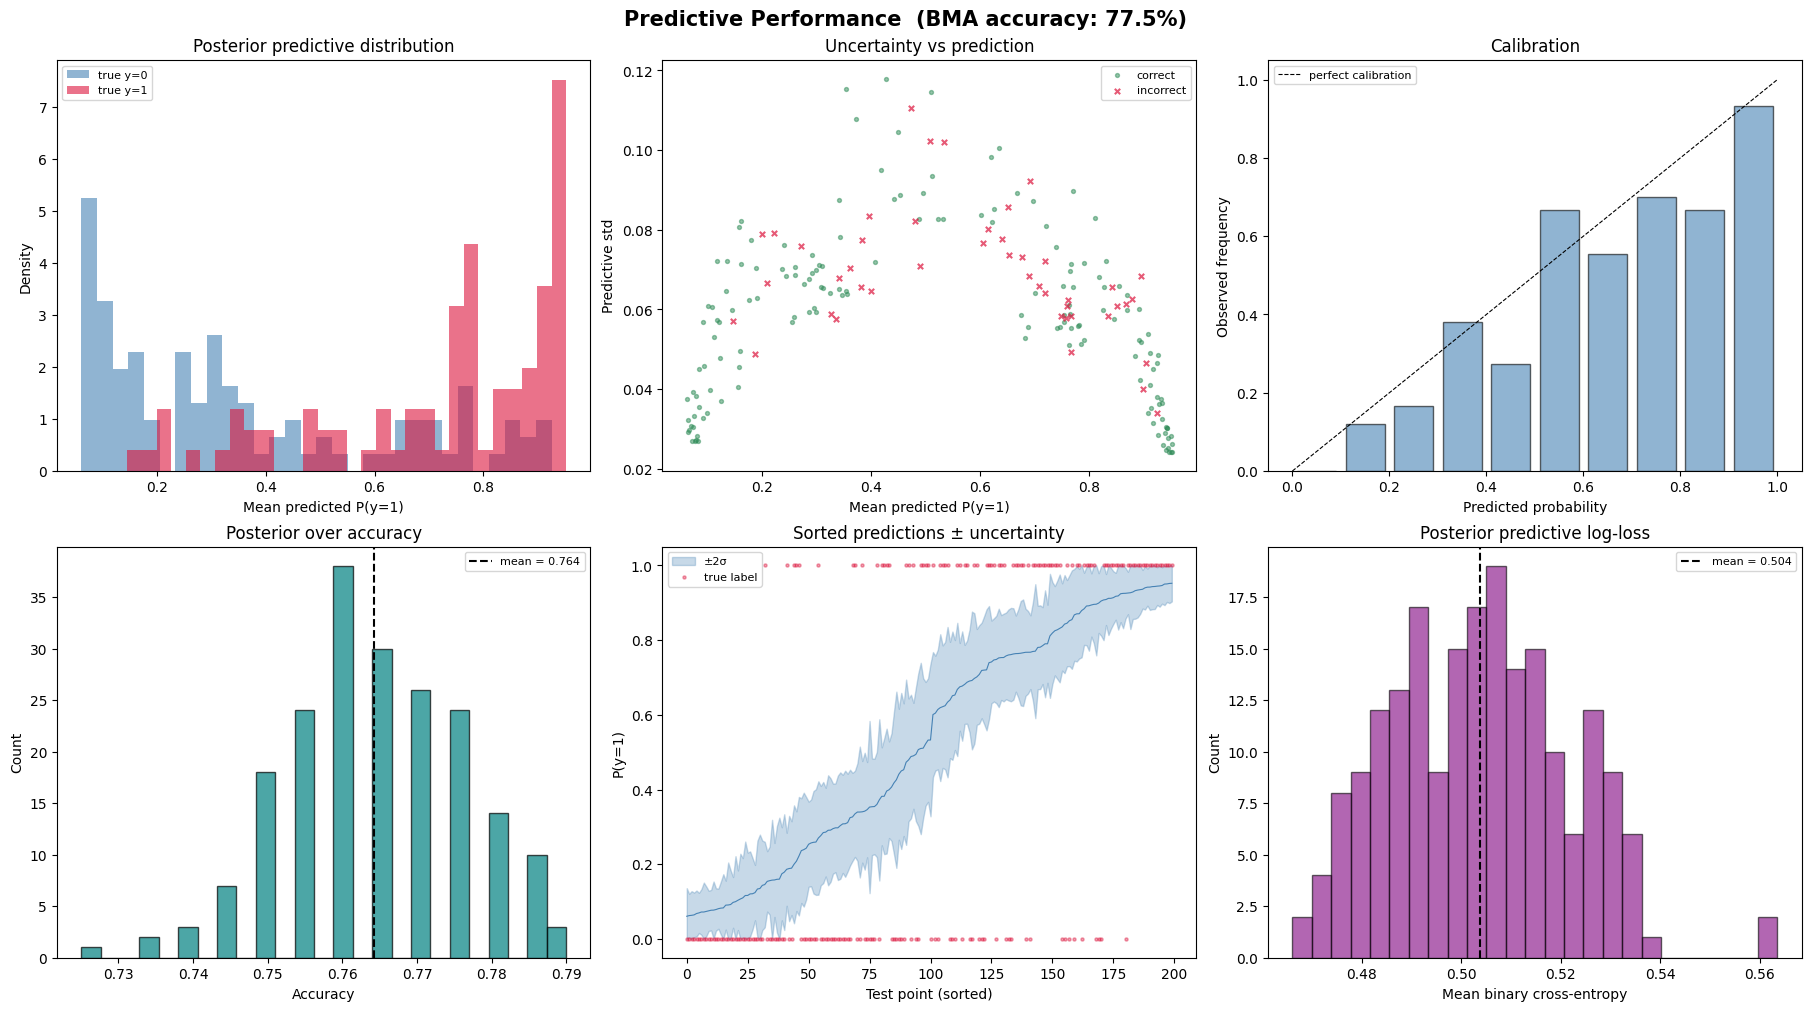

In [9]:
from bnn_testing.bnn_diagnostics import plot_bnn_diagnostics

figs = plot_bnn_diagnostics(
    sampler, X, y, layer_sizes=[d_in, H, 1],
    shapes=ws["shapes"], slices=ws["slices"], weight_mask=ws["weight_mask"],
    X_test=X_test, y_test=y_test,
)